In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

_ = np.loadtxt('J0_J40_T300_exocross.xsec')
print(_)
wavenumber, cross_sec = _[:, 0], _[:, 1]

__ = np.loadtxt('J0_J40_T500_exocross.xsec')
print(__)
wavenumber_, cross_sec_ = __[:, 0], __[:, 1]

___ = np.loadtxt('J0_J40_T1000_exocross.xsec')
print(___)
wavenumber__, cross_sec__ = ___[:, 0], ___[:, 1]

H2O_300_wave, H2O_300_xsec = np.loadtxt('H2O_T300.xsec',
                                unpack=True)

H2O_1000_wave, H2O_1000_xsec = np.loadtxt('H2O_T1000.xsec',
                                unpack=True)

[[0.00000000e+00 1.12322520e-24]
 [5.00000000e-01 4.05306984e-24]
 [1.00000000e+00 1.14681958e-23]
 ...
 [9.99900000e+03 7.37863028e-31]
 [9.99950000e+03 1.93226102e-32]
 [1.00000000e+04 1.39328865e-34]]
[[0.00000000e+00 1.09166582e-24]
 [5.00000000e-01 3.62756847e-24]
 [1.00000000e+00 8.72512431e-24]
 ...
 [9.99900000e+03 2.40060575e-31]
 [9.99950000e+03 6.28737973e-33]
 [1.00000000e+04 4.53415950e-35]]
[[0.00000000e+00 2.55336929e-24]
 [5.00000000e-01 7.42394813e-24]
 [1.00000000e+00 1.40794593e-23]
 ...
 [9.99900000e+03 3.15297522e-32]
 [9.99950000e+03 8.25873417e-34]
 [1.00000000e+04 5.95633903e-36]]


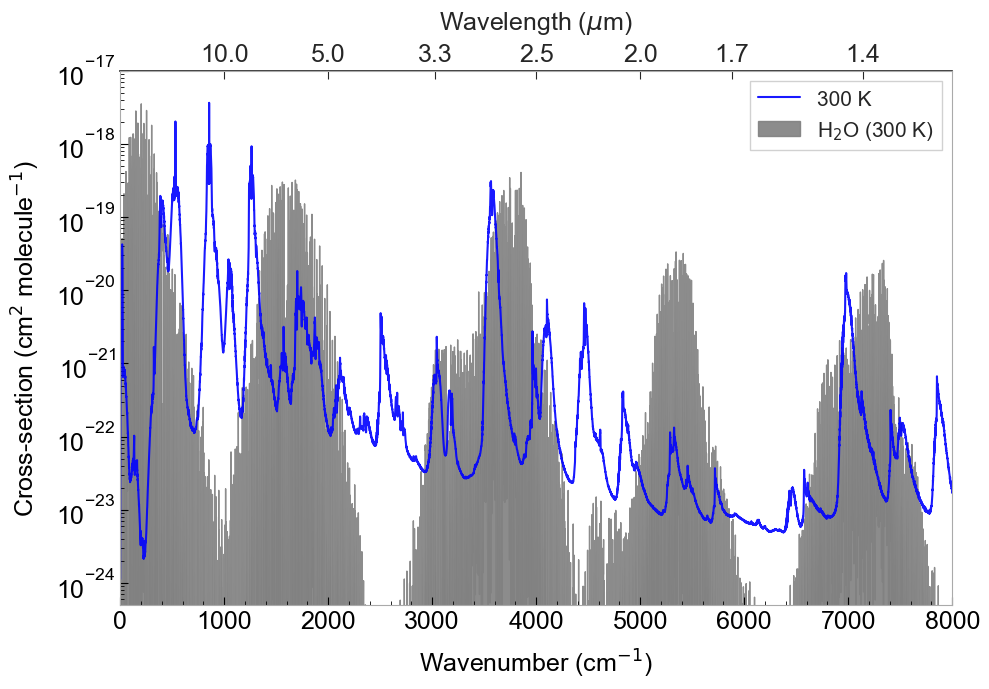

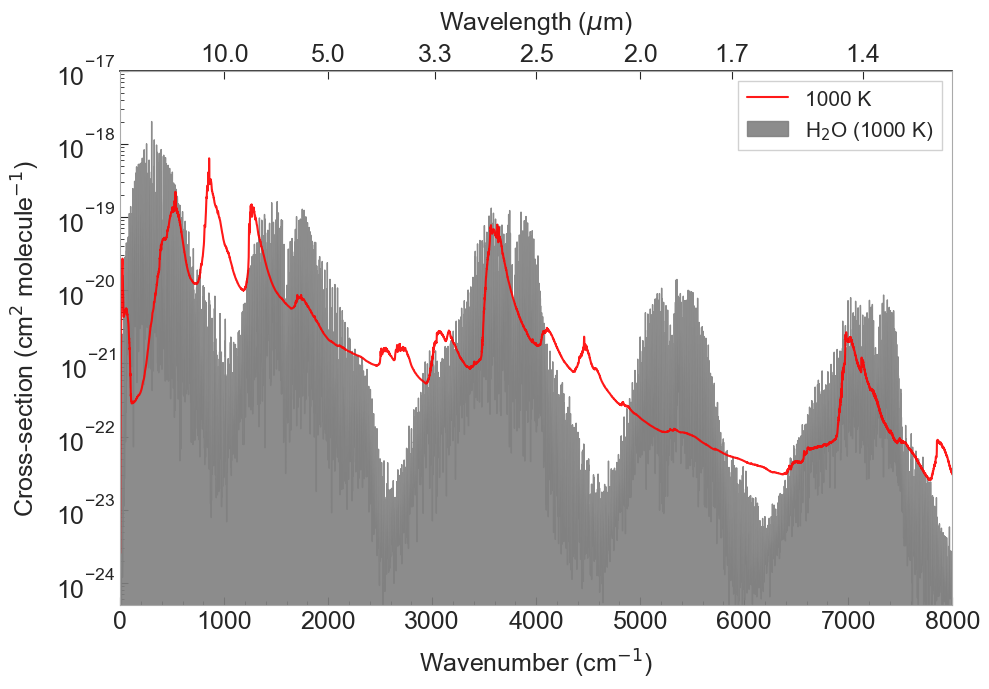

In [2]:
savefiles = ['H2O_T300.png', 'H2O_T1000.png']
HOPO_wave = [wavenumber, wavenumber__]
HOPO_xsec = [cross_sec, cross_sec__]
colors = ['blue', 'red']
HOPO_labels = ['300 K', '1000 K']
water_labels = ['H$_2$O (300 K)', 'H$_2$O (1000 K)']
water_wave = [H2O_300_wave, H2O_1000_wave]
water_xsec = [H2O_300_xsec, H2O_1000_xsec]

for i in range(2):
    fig, ax = plt.subplots(figsize=(10, 7))
    plt.style.use('seaborn-v0_8-white')  # No gridlines

    # Plot (other colors, #2196F3, #8E24AA, #E53935)
    ax.plot(HOPO_wave[i],  HOPO_xsec[i],  color=colors[i], linewidth=1.5, label=HOPO_labels[i], alpha=0.9)
    ax.fill_between(water_wave[i], water_xsec[i], color='grey', label=water_labels[i], alpha=0.9)

    # Log scale & axis limits
    ax.set_yscale('log')
    ax.set_xlim(0, 8000)
    ax.set_ylim(0.5e-24, 1e-17)

    # Primary x-axis (wavenumber)
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=18, labelpad=10)
    ax.set_ylabel(r'Cross-section (cm$^{2}$ molecule$^{-1}$)', fontsize=18, labelpad=10)
    #ax.set_title('Absorption Cross-Sections', fontsize=16, fontweight='bold', pad=40)

    # Ticks
    ax.tick_params(axis='both', which='major', labelsize=18, direction='in', length=6)
    ax.tick_params(axis='both', which='minor', direction='in', length=3)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # ── Secondary x-axis: wavelength (μm) ────────────────────────────────────────
    # Wavelength (μm) = 10 000 / wavenumber (cm⁻¹); nonlinear so we set explicit ticks
    ax_top = ax.secondary_xaxis('top')

    # Choose round wavelength values (μm) that fall within xlim (0–5000 cm⁻¹)
    wl_ticks_um = np.round(10000/np.arange(1000,10000,1000), decimals=1) # μm
    wn_positions = 10000 / wl_ticks_um   # cm⁻¹ positions

    ax_top.set_xticks(wn_positions)
    ax_top.set_xticklabels([str(w) for w in wl_ticks_um], fontsize=18)
    ax_top.set_xlabel(r'Wavelength ($\mu$m)', fontsize=18, labelpad=10)
    ax_top.tick_params(which='major', direction='in', length=6)

    # Legend
    ax.legend(
        fontsize=15,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
        fancybox=False,
        loc='best'
    )

    # Subtle border
    for spine in ax.spines.values():
        spine.set_edgecolor('#aaaaaa')
        spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.savefig(savefiles[i], transparent=True, dpi=300, bbox_inches='tight')
    plt.show()